# Environment setup and file tree Inspection

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_PATH = "/kaggle/input/datasets/prosenjitmondol/mimic-iv/mimic-iv-3.1"

# List directory contents and file sizes
def inspect_directory(base_dir):
    file_stats = []
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            full_path = os.path.join(root, f)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            rel_dir = os.path.relpath(root, base_dir)
            file_stats.append({
                "module": rel_dir if rel_dir != "." else "root",
                "filename": f,
                "size_mb": round(size_mb, 2)
            })
    return pd.DataFrame(file_stats).sort_values(by=["module", "size_mb"], ascending=[True, False])

df_files = inspect_directory(BASE_PATH)
df_files

,module,filename,size_mb
32,hosp,labevents.csv,17550.33
19,hosp,emar_detail.csv,8279.98
17,hosp,emar.csv,5959.05
12,hosp,poe.csv,4864.78
20,hosp,pharmacy.csv,3791.54
22,hosp,prescriptions.csv,3326.58
29,hosp,microbiologyevents.csv,867.12
30,hosp,poe_detail.csv,404.82
18,hosp,omr.csv,306.01
26,hosp,transfers.csv,195.75


# Demographics & Patient Overview

Total Unique Patients: 364,627
Total Admissions: 546,028


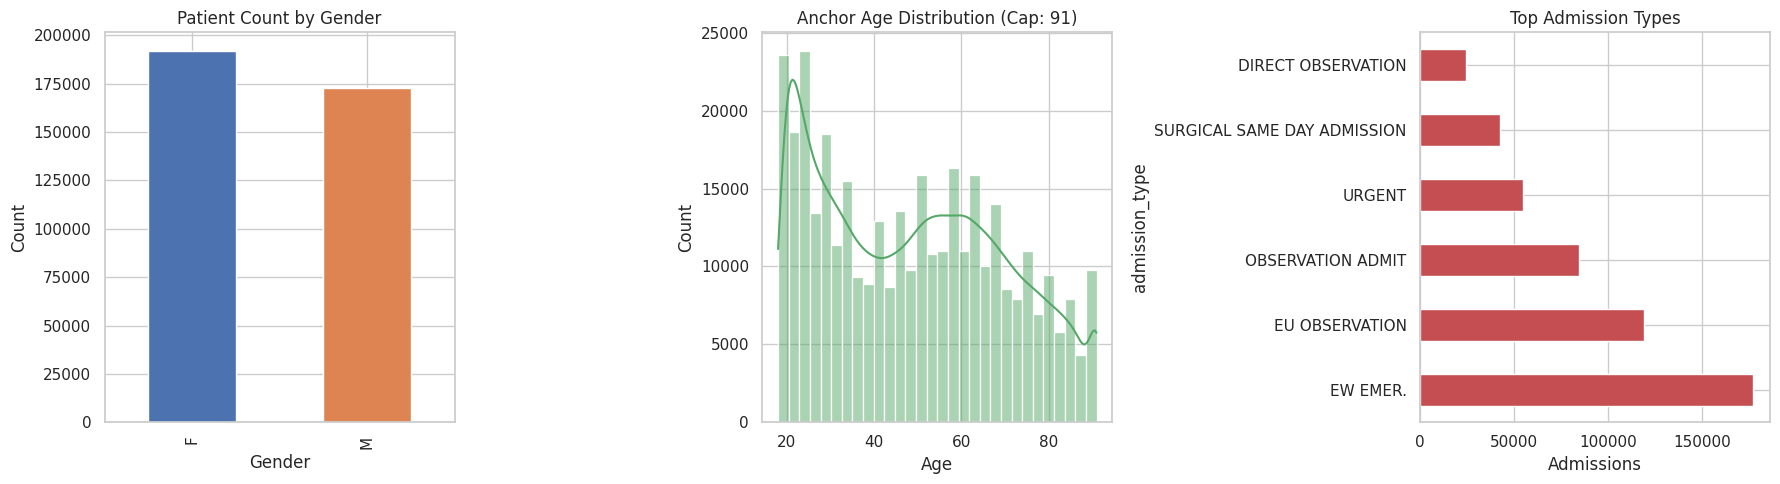

In [2]:
# Load patient demographics and admissions
patients_path = os.path.join(BASE_PATH, "hosp", "patients.csv")
admissions_path = os.path.join(BASE_PATH, "hosp", "admissions.csv")

df_patients = pd.read_csv(patients_path)
df_admissions = pd.read_csv(admissions_path)

print(f"Total Unique Patients: {df_patients['subject_id'].nunique():,}")
print(f"Total Admissions: {df_admissions['hadm_id'].nunique():,}")

# Visualizing Age Distribution and Gender
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gender distribution
df_patients['gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title("Patient Count by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# 2. Anchor Age distribution
sns.histplot(df_patients['anchor_age'], bins=30, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title("Anchor Age Distribution (Cap: 91)")
axes[1].set_xlabel("Age")

# 3. Admission Types
df_admissions['admission_type'].value_counts().head(6).plot(kind='barh', ax=axes[2], color='#C44E52')
axes[2].set_title("Top Admission Types")
axes[2].set_xlabel("Admissions")

plt.tight_layout()
plt.show()

# ICU Cohorts & Length of Stay

Total ICU Stays: 94,458
Unique ICU Patients: 65,366


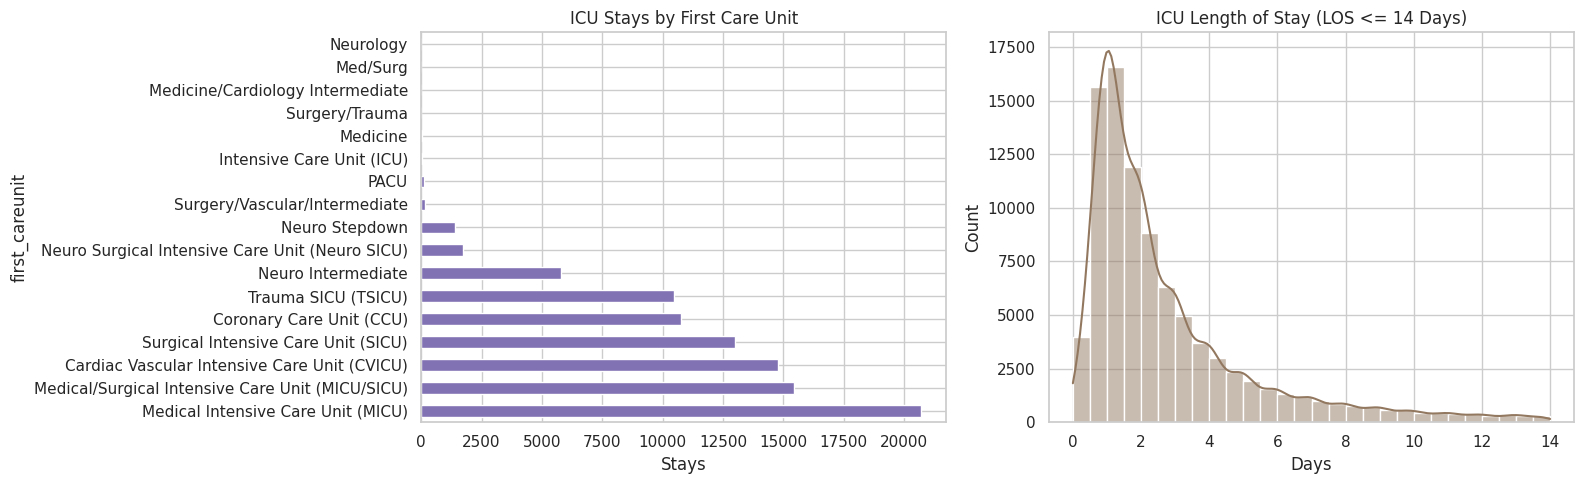

In [3]:
icustays_path = os.path.join(BASE_PATH, "icu", "icustays.csv")
df_icustays = pd.read_csv(icustays_path)

print(f"Total ICU Stays: {df_icustays['stay_id'].nunique():,}")
print(f"Unique ICU Patients: {df_icustays['subject_id'].nunique():,}")

# Filter LOS for visualization (remove extreme outliers for clear plotting)
los_filtered = df_icustays[df_icustays['los'] <= 14]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of ICU First Care Units
df_icustays['first_careunit'].value_counts().plot(kind='barh', ax=axes[0], color='#8172B3')
axes[0].set_title("ICU Stays by First Care Unit")
axes[0].set_xlabel("Stays")

# Length of Stay (LOS) in Days
sns.histplot(los_filtered['los'], bins=28, kde=True, ax=axes[1], color='#937860')
axes[1].set_title("ICU Length of Stay (LOS <= 14 Days)")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

# Diagnostic Profiling

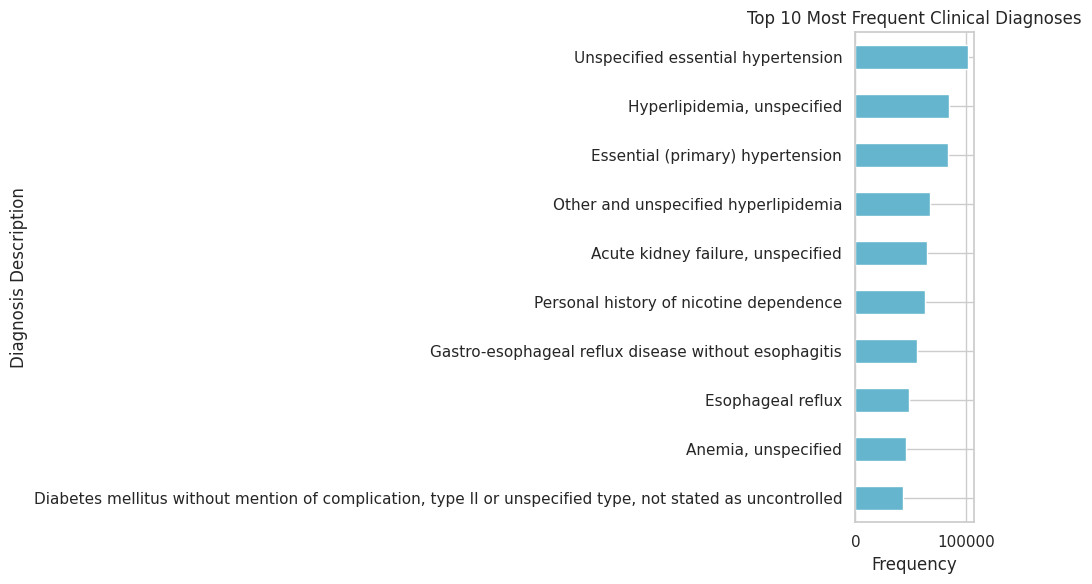

In [4]:
diag_path = os.path.join(BASE_PATH, "hosp", "diagnoses_icd.csv")
d_diag_path = os.path.join(BASE_PATH, "hosp", "d_icd_diagnoses.csv")

df_diag = pd.read_csv(diag_path)
df_d_diag = pd.read_csv(d_diag_path)

# Merge to get textual diagnoses
df_diag_named = df_diag.merge(df_d_diag, on=['icd_code', 'icd_version'], how='left')

# Top 10 most common clinical diagnoses
top_diagnoses = df_diag_named['long_title'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_diagnoses.sort_values().plot(kind='barh', color='#64B5CD')
plt.title("Top 10 Most Frequent Clinical Diagnoses")
plt.xlabel("Frequency")
plt.ylabel("Diagnosis Description")
plt.tight_layout()
plt.show()

# Large Table Chunking Pattern

Matched Items:
   itemid                    label unitname
2  220045               Heart Rate      bpm
3  220046  Heart rate Alarm - High      bpm
4  220047   Heart Rate Alarm - Low      bpm
Loaded 20,495 Heart Rate observations.


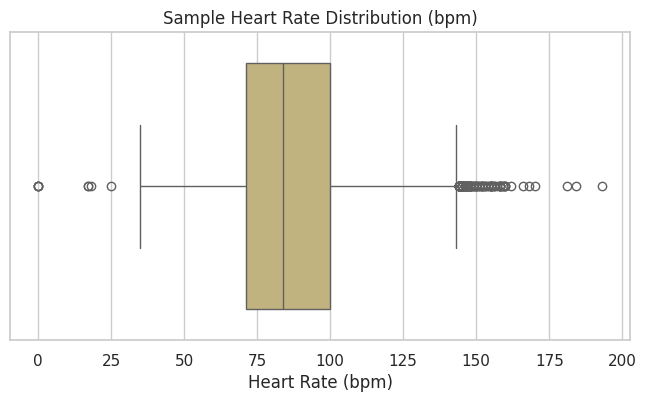

In [5]:
# 1. Look up item IDs for specific vitals (e.g., Heart Rate) in d_items
d_items_path = os.path.join(BASE_PATH, "icu", "d_items.csv")
df_items = pd.read_csv(d_items_path)

# Example: Finding Heart Rate Item ID (MetaVision itemid: 220045)
hr_item = df_items[df_items['label'].str.contains("Heart Rate", case=False, na=False)]
print("Matched Items:")
print(hr_item[['itemid', 'label', 'unitname']])

# 2. Stream chartevents by chunk to prevent Out-Of-Memory (OOM) errors
chartevents_path = os.path.join(BASE_PATH, "icu", "chartevents.csv")

hr_chunks = []
CHUNK_SIZE = 100_000

for chunk in pd.read_csv(chartevents_path, chunksize=CHUNK_SIZE, usecols=['subject_id', 'stay_id', 'charttime', 'itemid', 'valuenum']):
    # Filter for Heart Rate (itemid = 220045)
    filtered = chunk[chunk['itemid'] == 220045].dropna(subset=['valuenum'])
    hr_chunks.append(filtered)
    
    # Break early after collecting enough samples for exploration
    if len(hr_chunks) * CHUNK_SIZE >= 1_000_000:
        break

df_sample_hr = pd.concat(hr_chunks, ignore_index=True)
print(f"Loaded {len(df_sample_hr):,} Heart Rate observations.")

# Plot sample vital distributions
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sample_hr['valuenum'], color='#CCB974')
plt.title("Sample Heart Rate Distribution (bpm)")
plt.xlabel("Heart Rate (bpm)")
plt.show()